<a href="https://colab.research.google.com/github/nkoti1289/unemployment_data_analysis/blob/main/zomato%20dataset%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [21]:
df = pd.read_csv('/content/Unemployment in India.csv')
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)



Dataset Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [23]:
df.columns = df.columns.str.strip()

print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("\nCleaned Dataset Shape:", df.shape)
df.columns = df.columns.str.strip()

print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("\nCleaned Dataset Shape:", df.shape)




Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Cleaned Dataset Shape: (740, 7)

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Cleaned Dataset Shape: (740, 7)


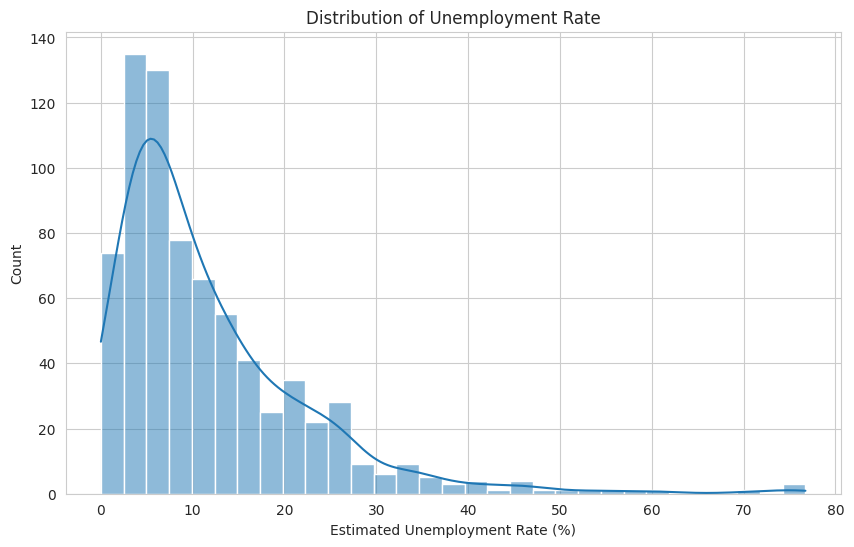

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True)
plt.title('Distribution of Unemployment Rate')
plt.show()


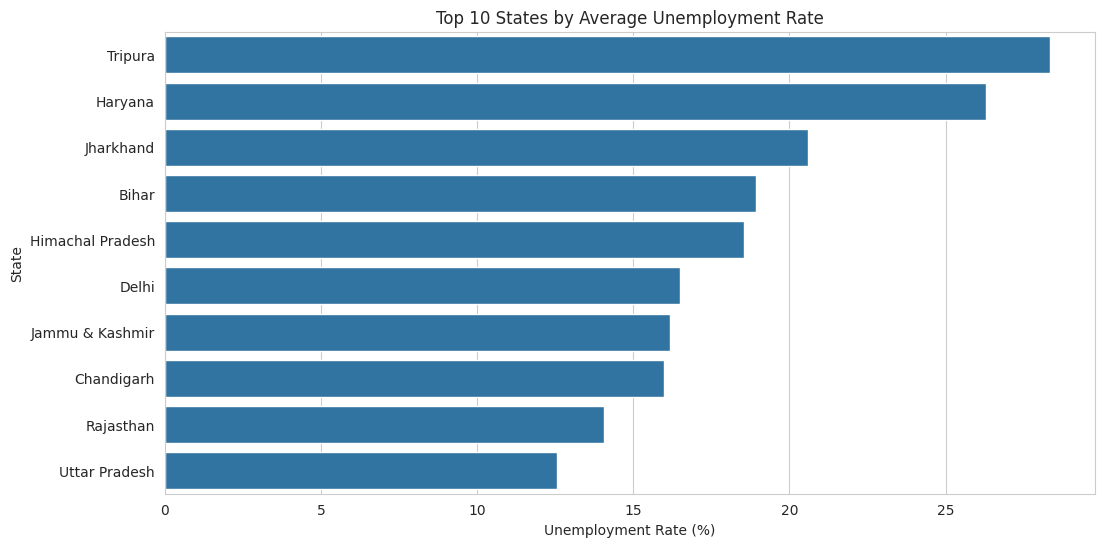

In [28]:


state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top10 = state_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State')
plt.show()



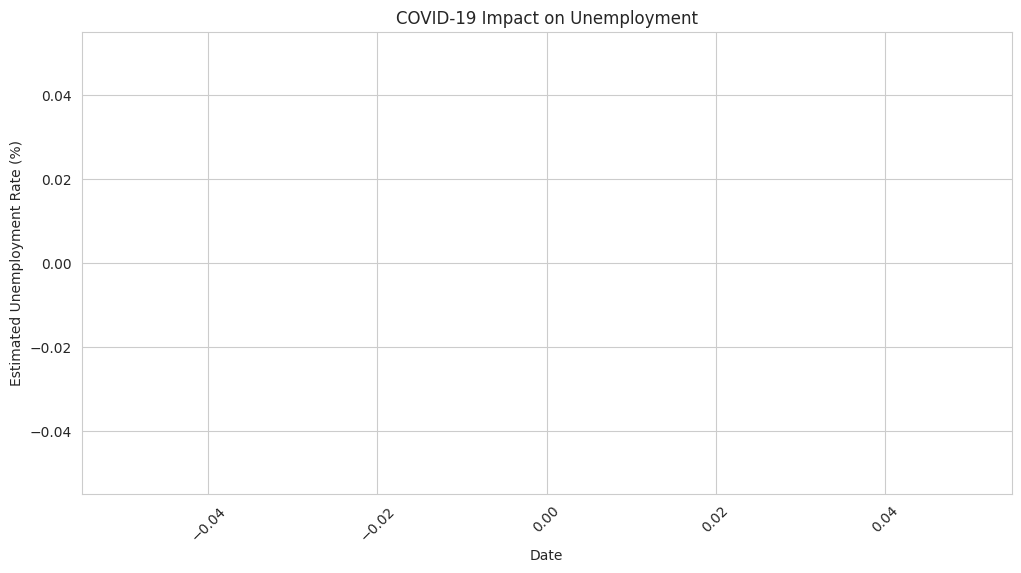

In [29]:
covid_data = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(12,6))
sns.lineplot(
    data=covid_data,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)
plt.title('COVID-19 Impact on Unemployment')
plt.xticks(rotation=45)
plt.show()



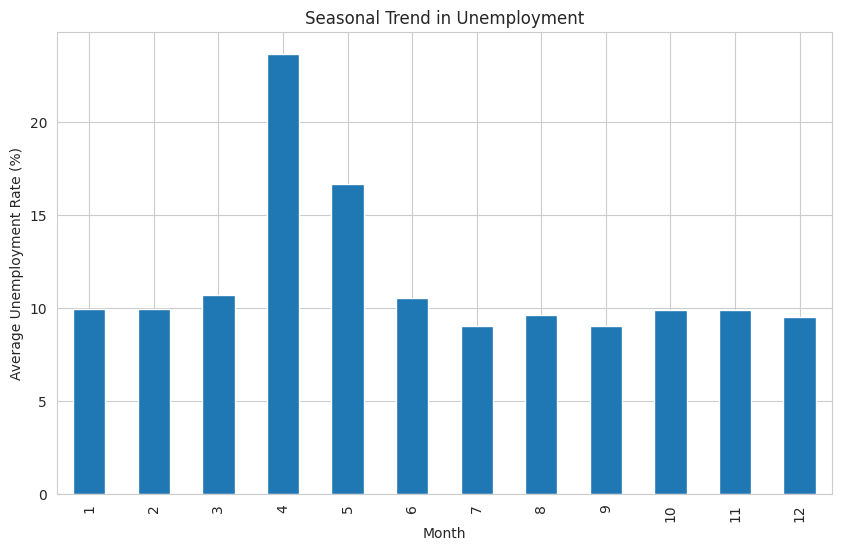

In [32]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,6))
monthly_avg.plot(kind='bar')
plt.title('Seasonal Trend in Unemployment')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

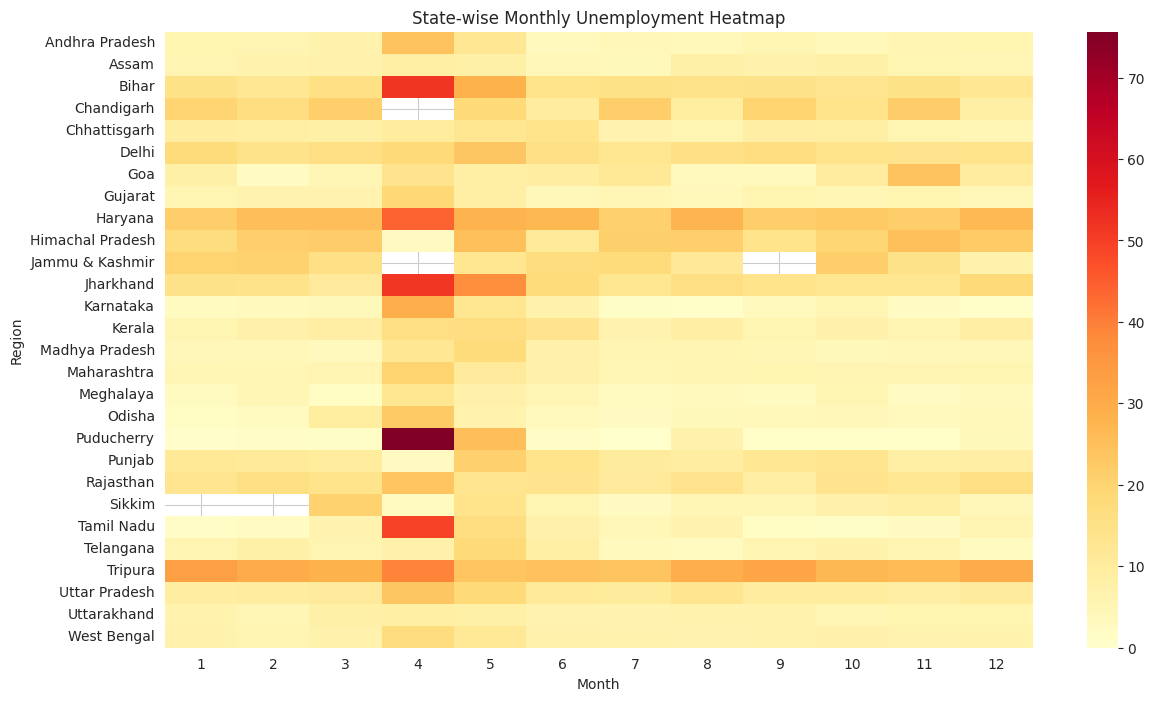

In [33]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('State-wise Monthly Unemployment Heatmap')
plt.show()

In [34]:
print("\n========== KEY INSIGHTS ==========")

print(f"Average Unemployment Rate: "
      f"{df['Estimated Unemployment Rate (%)'].mean():.2f}%")

print(f"Highest Unemployment Rate: "
      f"{df['Estimated Unemployment Rate (%)'].max():.2f}%")

print(f"Lowest Unemployment Rate: "
      f"{df['Estimated Unemployment Rate (%)'].min():.2f}%")

print("\nCONCLUSION:")
print("- Unemployment increased significantly during COVID-19.")
print("- Some states experienced higher unemployment than others.")
print("- Seasonal variations are visible across months.")
print("- Government employment policies can target high-risk regions.")
print("- Continuous monitoring helps improve economic planning.")


========== KEY INSIGHTS ==========
Average Unemployment Rate: 11.79%
Highest Unemployment Rate: 76.74%
Lowest Unemployment Rate: 0.00%

CONCLUSION:
- Unemployment increased significantly during COVID-19.
- Some states experienced higher unemployment than others.
- Seasonal variations are visible across months.
- Government employment policies can target high-risk regions.
- Continuous monitoring helps improve economic planning.
